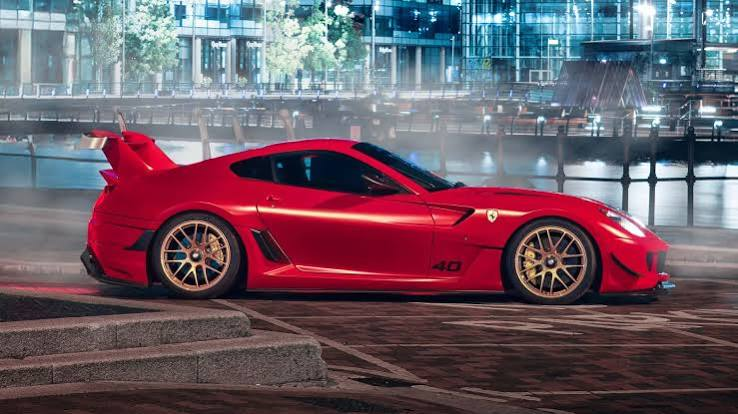

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
img = cv2.imread('/content/car.jpeg')
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()

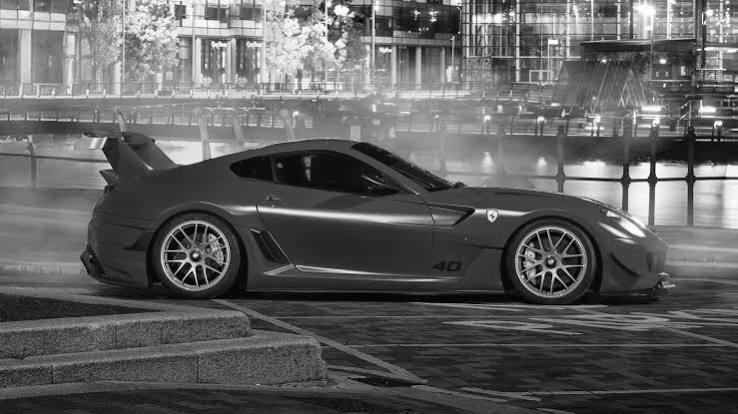

In [ ]:
grayimg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(grayimg)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import numpy as np

def custom_spatial_hpf(image: np.ndarray) -> np.ndarray:

    img_float = image.astype(np.float32)
    output_image = np.zeros_like(img_float)

    kernel = np.array([[-1, -1, -1],
                       [-1,  8, -1],
                       [-1, -1, -1]])

    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2

    height, width = img_float.shape

    for i in range(height):
        for j in range(width):

            sum_val = 0.0
            for ki in range(k_h):
                for kj in range(k_w):

                    img_i = i - pad_h + ki
                    img_j = j - pad_w + kj

                    if img_i < 0: img_i = -img_i
                    if img_i >= height: img_i = height - (img_i - height + 1)
                    if img_j < 0: img_j = -img_j
                    if img_j >= width: img_j = width - (img_j - width + 1)

                    sum_val += img_float[img_i, img_j] * kernel[ki, kj]
            output_image[i, j] = sum_val

    return np.clip(output_image, 0, 255).astype(np.uint8)

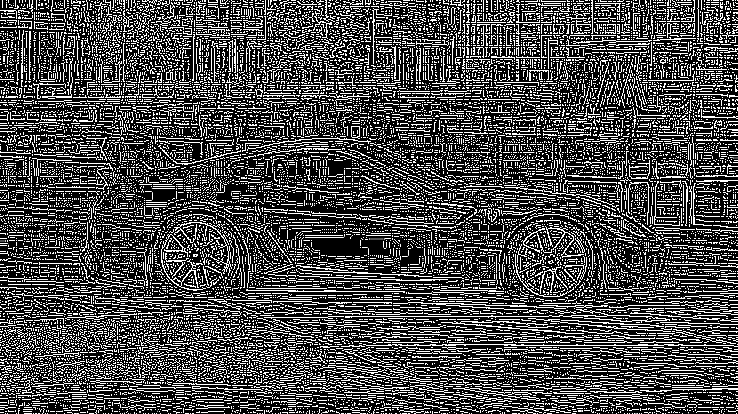

In [ ]:
hp = custom_spatial_hpf(grayimg)
cv2_imshow(hp)
cv2.waitKey(0)
cv2.destroyAllWindows()

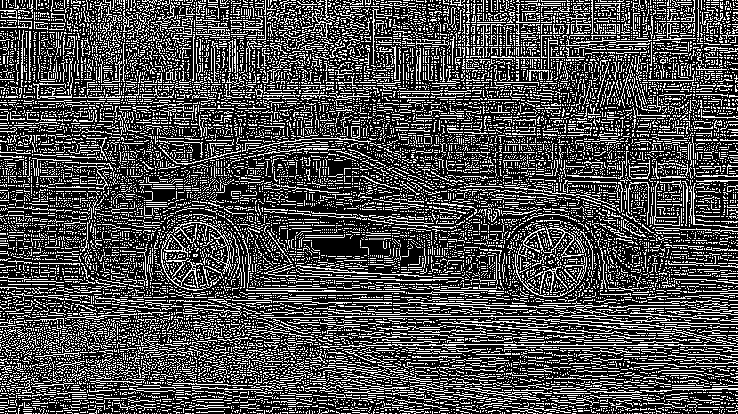

In [ ]:
def custom_hb(image: np.ndarray, hp) -> np.ndarray:

    img_float = image.astype(np.float32)
    a = 1.2

    out = a*img_float + hp
    return out

highboost = custom_hb(grayimg,hp)
cv2_imshow(highboost)
cv2.waitKey(0)
cv2.destroyAllWindows()